# KRONOS — Verifier-Guided Multimodal Tree Search for Chest X-ray VQA

This notebook walks through every stage of the pipeline on a **real X-ray**,
using the **real frozen models** (YOLOv12, MedGemma-4b, BiomedCLIP).

The key idea borrowed from **Tree of Thoughts** (Yao et al., NeurIPS 2023):
frame the question as a **tree search** — the LLM proposes branches, a value
function scores them, the best branch is expanded. But KRONOS replaces the
LLM self-evaluation with a **deterministic verifier on a clinical ontology**,
so every answer is traceable and the system **never trusts the LLM blindly**.

```
  X-ray image ─► [1] YOLOv12 Detector  ──► PerceptualFacts (grounded findings)
  question    ─► [2] Rule-Based Parser  ──► Query(type, target)
                                               │
               ┌───────────────────────────────┘
               ▼
     [3] Tree Search (best-first, budget=20)
               │
               │  ┌─ [4] MedGemma (frozen): proposes Actions or Answer
               ├──┤  [5] Tools: symbolic (DAG) / visual / RAG retrieval
               │  └─ [6] Verifier: closure_progress (scores) + verify (tier gate)
               │
               ▼
     SearchResult(answer, tier={A,B,ABSTAIN}, trace)
```

> Run in the `medcxr` conda env. Needs GPU free (~3 GB VRAM for 4-bit MedGemma).

---
## Setup

In [1]:
import os, sys, json
os.environ['HF_HUB_OFFLINE'] = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'
from pathlib import Path
from PIL import Image, ImageDraw
sys.path.insert(0, '.')

DATA = Path('data')
DEMO_ID = '9a5094b2563a1ef3ff50dc5c7ff71345'
DEMO_IMG = DATA / 'vindr_cxr_vqa' / 'train' / f'{DEMO_ID}.png'
image = Image.open(DEMO_IMG).convert('RGB')
W, H = image.size
print(f'Image: {DEMO_IMG.name}  size={W}x{H}')

Image: 9a5094b2563a1ef3ff50dc5c7ff71345.png  size=512x512


---
## Stage 1 — Perception: YOLOv12 → PerceptualFacts

The frozen YOLOv12 detector is the **only** source of visual ground truth.
Everything downstream reasons over these facts — never over raw pixels.

Each fact = `(concept, bbox, laterality, confidence)`.

In [2]:
from src.ontology.dag import OntologyDAG
from src.perception.detector import Detector

dag = OntologyDAG(
    'data/ontology/dag.yaml',
    'data/ontology/exclusion_lists.yaml',
    'data/ontology/anatomy_zones.yaml',
)
detector = Detector('weights/yolov12s_vindr.pt', dag=dag)

facts = detector.detect(str(DEMO_IMG))
print(f'Detected {len(facts)} findings:\n')
for f in facts:
    zone = dag.anatomy_of(f.bbox, W, H) or '?'
    print(f'  {f.concept:16s}  conf={f.conf:.2f}  lat={f.laterality:9s}  zone={zone}')
    print(f'  {" "*16}  bbox=({f.bbox[0]:.0f}, {f.bbox[1]:.0f}, {f.bbox[2]:.0f}, {f.bbox[3]:.0f})')

Detected 2 findings:

  Nodule/Mass       conf=0.72  lat=bilateral  zone=heart
                    bbox=(170, 301, 416, 394)
  Consolidation     conf=0.36  lat=midline    zone=mediastinum
                    bbox=(269, 156, 319, 205)


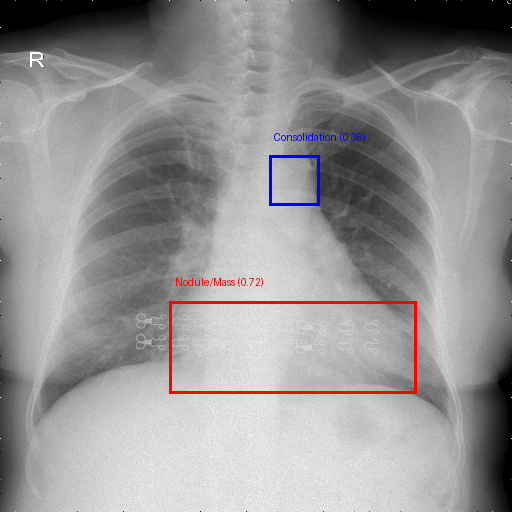

In [3]:
vis = image.copy()
draw = ImageDraw.Draw(vis)
colors = ['red', 'blue', 'green', 'orange']
for i, f in enumerate(facts):
    c = colors[i % len(colors)]
    draw.rectangle(f.bbox, outline=c, width=3)
    draw.text((f.bbox[0]+5, max(0, f.bbox[1]-25)),
              f'{f.concept} ({f.conf:.2f})', fill=c)
vis.thumbnail((512, 512))
vis

---
## Stage 2 — Question Parsing: text → Query

Rule-based parser → `Query(type, target, constraints)`. The **type** decides:
- which tools the agent should use
- which verifier rule checks the answer
- what counts as 'closure' (search complete)

| Type | Example | Verifier needs |
|---|---|---|
| `existential` | 'Is there Cardiomegaly?' | `is_a` witness OR closed-world absence |
| `negation` | 'Are lungs clear of X?' | exclusion list fully checked |
| `relational` | 'Where is X?' | `anatomy_of` or `compose_laterality` result |
| `counting` | 'How many findings?' | count of distinct facts |
| `open` | 'What abnormality?' | free text (tier B only) |

In [4]:
from src.question.parser import QuestionParser
from src.pipeline import VINDR_FINDINGS

parser = QuestionParser(finding_vocab=VINDR_FINDINGS)

demo_questions = [
    'Does this X-ray show Cardiomegaly?',
    'Are the lungs clear of Pneumothorax?',
    'Where is the Cardiomegaly?',
    'Which side shows the abnormality?',
    'How many findings are there?',
    'What abnormality is visible?',
]
for q in demo_questions:
    p = parser.parse(q)
    print(f'  {p.type:12s}  target={str(p.target):20s}  <- "{q}"')

  existential   target=Cardiomegaly          <- "Does this X-ray show Cardiomegaly?"
  negation      target=Pneumothorax          <- "Are the lungs clear of Pneumothorax?"
  relational    target=Cardiomegaly          <- "Where is the Cardiomegaly?"
  relational    target=None                  <- "Which side shows the abnormality?"
  counting      target=None                  <- "How many findings are there?"
  open          target=None                  <- "What abnormality is visible?"


---
## Stage 3 — Ontology DAG: the symbolic 'brain'

A hand-curated graph of ~33 nodes with 4 relation types:

```
Abnormality
├── Cardiac abnormality
│   └── Cardiomegaly           ← is-a → Cardiac abnormality → Abnormality
├── Pulmonary abnormality
│   ├── Airspace abnormality
│   │   ├── Consolidation      ← detected!
│   │   ├── Infiltration
│   │   ├── Lung Opacity
│   │   └── Atelectasis
│   ├── Interstitial abnormality
│   │   ├── ILD
│   │   └── Pulmonary fibrosis
│   └── Nodule/Mass            ← detected!
├── Pleural abnormality
│   ├── Pleural effusion
│   ├── Pleural thickening
│   └── Pneumothorax
└── Vascular abnormality
    └── Aortic enlargement
```

The tools are thin wrappers — each just traverses this graph.

In [5]:
# is_a: walk up the tree, return path or None
print('cardiomegaly → cardiac_abnormality:',
      dag.reachable_is_a('cardiomegaly', 'cardiac_abnormality'))
print('consolidation → cardiomegaly     :',
      dag.reachable_is_a('consolidation', 'cardiomegaly'))

# exclusion list: what must ALL be absent before we can say 'No X'?
print('\nexclusion(Consolidation):', dag.get_exclusion_list('Consolidation'))
print('  → must rule out consolidation AND infiltration AND lung_opacity')

# anatomy: which zone does a bbox overlap most?
print('\nanatomy_of(first fact bbox):', dag.anatomy_of(facts[0].bbox, W, H))

# laterality: left/right/bilateral/midline from bbox position
print('laterality(first fact bbox):', dag.compose_laterality(facts[0].bbox, W, H))

# disjoint: can two findings coexist in the same region?
print('\npneumothorax ⊥ pleural_effusion:', dag.disjoint('pneumothorax', 'pleural_effusion'))

cardiomegaly → cardiac_abnormality: ['cardiomegaly', 'cardiac_abnormality']
consolidation → cardiomegaly     : None

exclusion(Consolidation): ['consolidation', 'infiltration', 'lung_opacity']
  → must rule out consolidation AND infiltration AND lung_opacity

anatomy_of(first fact bbox): heart
laterality(first fact bbox): bilateral

pneumothorax ⊥ pleural_effusion: True


---
## Stage 4 — Load frozen neural models

| Model | Role | Size on GPU |
|---|---|---|
| **MedGemma-4b-it** (4-bit) | Agent: proposes tool calls | ~2.5 GB |
| **BiomedCLIP** | RAG encoder: image → embedding | ~0.4 GB |
| **YOLOv12s** | Detector (already loaded) | ~0.1 GB |

The agent only *proposes* — the verifier *decides*. No model is fine-tuned.

In [6]:
from src.agent.medgemma import MedGemmaAgent
from src.retrieval.index import RagIndex
from src.retrieval.retriever import Retriever
from src.retrieval.encoder import load_encoder

print('Loading MedGemma-4b (4-bit)...')
agent = MedGemmaAgent(model_path='weights/medgemma-4b-it', quantize=True, load_model=True)

print('Loading BiomedCLIP + FAISS index...')
cases = [json.loads(l) for l in open('data/rag/vindr_cases.jsonl', encoding='utf-8')]
index = RagIndex.load(Path('data/rag/vindr_index.faiss'), cases)
encoder = load_encoder(model_path='weights/BiomedCLIP', device='cuda')
retriever = Retriever(index=index, encoder=encoder)
print(f'RAG index: {index._index.ntotal} cases')
print('All models loaded.')

Loading MedGemma-4b (4-bit)...


h:\Setup\Anacoda\envs\medcxr\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:11<00:00,  5.79s/it]


Loading BiomedCLIP + FAISS index...
RAG index: 4394 cases
All models loaded.


---
## Stage 5 — Inside MedGemma: prompt → raw output → parsed actions

Let's see **exactly** what MedGemma receives and produces. The prompt includes:
- System instructions with strategy per question type
- The question + detected facts
- History of actions taken so far
- Available tools list

MedGemma outputs either:
- A JSON array of tool calls: `[{"tool": "is_a", "args": {...}}]`
- Or a final answer: `Answer[Yes]`

In [ ]:
from src.agent.prompt import build_prompt, parse_output
from src.contracts import TreeNode
from src.engine.verifier import closure_progress

agent.set_image(image)
query = parser.parse('Does this X-ray show Cardiomegaly?')

root = TreeNode(state_facts=list(facts), history=[])
root = root.model_copy(update={'reward': closure_progress(root, query, dag)})

# Build the prompt MedGemma sees
prompt = build_prompt(root, query, k=3)
print('═══ PROMPT TO MEDGEMMA ═══')
print(prompt)

═══ PROMPT TO MEDGEMMA (truncated) ═══
You are a medical VQA reasoning agent. You answer chest X-ray questions by calling tools, then emitting Answer[...] when you have enough evidence.

STRATEGY BY QUESTION TYPE:

existential ("Is there X?"):
  1. For each base fact, call is_a(fact, target) to check if it witnesses the target.
  2. If any returns a path → emit Answer[Yes].
  3. If none match and you suspect a missed finding → call re_detect(bbox) on a likely region, then retry is_a on new facts.
  4. If still no witness → emit Answer[No].

negation ("Is there NO X?" / "Are the lungs clear?"):
  1. Call get_exclusion_list(target) first.
  2. For each item in the list, check if any base fact matches via is_a.
  3. If ANY match is found → emit Answer[No] (finding IS present, so "no X" is false).
  4. If ALL items are checked and absent → emit Answer[Yes] (confirmed absent).

relational ("Where is X?" / "Which side?"):
  1. Find the fact matching the target.
  2. Call anatomy_of(bbox) or 

In [8]:
# Run MedGemma and show raw output
raw_output = agent._run_model(prompt)
print('═══ RAW MEDGEMMA OUTPUT ═══')
print(raw_output)

# Parse into structured Actions
proposals = parse_output(raw_output)
print('\n═══ PARSED PROPOSALS ═══')
for p in proposals:
    if isinstance(p, str):
        print(f'  Answer: {p!r}')
    else:
        print(f'  Tool call: {p.tool}({p.args})  kind={p.kind}')

═══ RAW MEDGEMMA OUTPUT ═══
```json
[
  {"tool": "is_a", "args": {"node": "cardiomegaly", "target": "cardiac_abnormality"}},
  {"tool": "inspect", "args": {"bbox": "cardiomegaly"}},
  {"tool": "compare", "args": {"bbox1": "cardiomegaly", "bbox2": "cardiomegaly"}}
]
```

═══ PARSED PROPOSALS ═══
  Tool call: is_a({'node': 'cardiomegaly', 'target': 'cardiac_abnormality'})  kind=symbolic
  Tool call: inspect({'bbox': 'cardiomegaly'})  kind=visual
  Tool call: compare({'bbox1': 'cardiomegaly', 'bbox2': 'cardiomegaly'})  kind=visual


---
## Stage 6 — Tool execution: symbolic + visual + retrieval

Each proposed Action goes to `run_tool()`, which routes it:
- **Symbolic** tools → DAG traversal (instant, deterministic)
- **Visual** tools → crop image + run detector/VLM (slower)
- **Retrieve** → BiomedCLIP encode → FAISS search

In [9]:
from src.tools.dispatch import run_tool
from src.contracts import Action

# Demo each tool type:

# 1) is_a — does Nodule/Mass witness Cardiomegaly?
act = Action(tool='is_a', args={'node': 'nodule_mass', 'target': 'cardiomegaly'})
obs = run_tool(act, facts, dag, img_wh=(W, H))
print(f'is_a(nodule_mass, cardiomegaly) → result={obs.result}  ok={obs.ok}')
print('  → Nodule/Mass is NOT a type of Cardiomegaly (different branch on DAG)\n')

# 2) is_a — does Consolidation witness Airspace abnormality?
act2 = Action(tool='is_a', args={'node': 'consolidation', 'target': 'airspace_abnormality'})
obs2 = run_tool(act2, facts, dag, img_wh=(W, H))
print(f'is_a(consolidation, airspace_abnormality) → result={obs2.result}  ok={obs2.ok}')
print('  → YES: consolidation → airspace_abnormality (1 hop on DAG)\n')

# 3) anatomy_of — where is this finding?
act3 = Action(tool='anatomy_of', args={'bbox': list(facts[0].bbox)})
obs3 = run_tool(act3, facts, dag, img_wh=(W, H))
print(f'anatomy_of(bbox of {facts[0].concept}) → result={obs3.result!r}  ok={obs3.ok}')

# 4) compose_laterality — which side?
act4 = Action(tool='compose_laterality', args={'bbox': list(facts[0].bbox)})
obs4 = run_tool(act4, facts, dag, img_wh=(W, H))
print(f'compose_laterality(bbox) → result={obs4.result!r}  ok={obs4.ok}')

is_a(nodule_mass, cardiomegaly) → result=None  ok=False
  → Nodule/Mass is NOT a type of Cardiomegaly (different branch on DAG)

is_a(consolidation, airspace_abnormality) → result=['consolidation', 'airspace_abnormality']  ok=True
  → YES: consolidation → airspace_abnormality (1 hop on DAG)

anatomy_of(bbox of Nodule/Mass) → result='heart'  ok=True
compose_laterality(bbox) → result='bilateral'  ok=True


In [10]:
# 5) RAG retrieval — find similar cases with BiomedCLIP
retriever.set_query_emb(encoder.encode(image))
act5 = Action(tool='retrieve', args={'k': 3})
obs5 = run_tool(act5, facts, dag, img_wh=(W, H), retriever=retriever)
print('retrieve(k=3) → top-3 similar training cases:\n')
for c in obs5.result:
    print(f'  score={c["score"]:.3f}  labels={c["labels"]}')

retrieve(k=3) → top-3 similar training cases:

  score=1.000  labels=['Cardiomegaly']
  score=0.959  labels=['Cardiomegaly']
  score=0.951  labels=['Calcification']


---
## Stage 7 — Verifier: the only authority

Two roles:

| Function | Returns | Purpose |
|---|---|---|
| `closure_progress(node, query, dag)` | `float` [0, 1] | **Search heuristic**: how close is this node to a verified answer? |
| `verify(node, query, dag)` | `SearchResult(tier)` | **Terminal gate**: is this answer trustworthy enough to emit? |

**Key difference vs ToT**: ToT asks the LLM to evaluate itself
('sure/maybe/impossible'). KRONOS never asks the LLM — the verifier
checks the DAG and only the DAG.

In [11]:
from src.engine.verifier import closure_progress, verify
from src.contracts import Action, Observation

# Fresh node — no actions taken yet
print('═══ VERIFIER SCORING ═══\n')
print(f'Root node (no actions yet):  reward = {root.reward:.2f}')

# After a FAILED is_a check
fail_step = (
    Action(tool='is_a', args={'node': 'nodule_mass', 'target': 'cardiomegaly'}),
    Observation(result=None, ok=False),
)
node_1 = TreeNode(state_facts=list(facts), history=[fail_step])
node_1 = node_1.model_copy(update={'reward': closure_progress(node_1, query, dag)})
print(f'After is_a(nodule_mass→cardiomegaly)=FAIL:  reward = {node_1.reward:.2f}')

# After ALL facts checked and none match → closed-world 'No'
fail_step2 = (
    Action(tool='is_a', args={'node': 'consolidation', 'target': 'cardiomegaly'}),
    Observation(result=None, ok=False),
)
node_2 = TreeNode(state_facts=list(facts), history=[fail_step, fail_step2], answer='No')
result = verify(node_2, query, dag)
print(f'After ALL is_a checks fail → verify():  tier={result.tier}  answer={result.answer!r}')
print(f'  → Closed-world: Cardiomegaly is in DAG, no fact is-a it → confirmed absent → tier A')

═══ VERIFIER SCORING ═══

Root node (no actions yet):  reward = 0.20
After is_a(nodule_mass→cardiomegaly)=FAIL:  reward = 0.20
After ALL is_a checks fail → verify():  tier=A  answer='No'
  → Closed-world: Cardiomegaly is in DAG, no fact is-a it → confirmed absent → tier A


---
## Stage 8 — Tree search: step-by-step trace

This is the **core of KRONOS**. We instrument the search loop to show
every iteration: which node is expanded, what MedGemma proposes, what tools
return, how the verifier scores each child, and how the frontier evolves.

Compare with **ToT Algorithm 1 (BFS)** from Yao et al.:
- ToT: LLM generates k thoughts → LLM evaluates them → keep best b
- KRONOS: LLM proposes k actions → tools execute → **verifier** scores → expand best

In [12]:
from src.contracts import TreeNode, SearchResult
from src.tools.dispatch import run_tool
from src.tools.visual import fold_facts
from src.engine.verifier import closure_progress, verify
from src.ontology.dag import slugify
from src.agent.prompt import parse_output

def traced_search(query, facts, dag, agent, budget=20, k=3, img_wh=None,
                  image=None, retriever=None):
    """Same logic as tree_search.search(), but prints every step."""
    if img_wh is None:
        img_wh = (2304, 2880)

    root = TreeNode(state_facts=list(facts), history=[])
    root = root.model_copy(update={'reward': closure_progress(root, query, dag)})
    frontier = [root]
    best_tier_b = None
    nodes_expanded = 0

    print(f'Question: "{query.raw_question}"')
    print(f'Type: {query.type}  Target: {query.target}')
    print(f'Facts: {[(f.concept, round(f.conf,2)) for f in facts]}')
    print(f'Budget: {budget}  k: {k}')
    print('=' * 70)

    while frontier and nodes_expanded < budget:
        frontier.sort(key=lambda n: n.reward, reverse=True)
        node = frontier.pop(0)
        nodes_expanded += 1

        print(f'\n┌─ Iteration {nodes_expanded}  (frontier size: {len(frontier)+1})')
        print(f'│  Expanding node: reward={node.reward:.2f}, history_len={len(node.history)}')

        proposals = agent.propose_actions(node, query, k)
        print(f'│  MedGemma proposed {len(proposals)} actions:')

        for j, proposal in enumerate(proposals):
            if isinstance(proposal, str):
                print(f'│    [{j}] Answer: {proposal!r}')
                child = node.model_copy(update={'answer': proposal, 'parent_id': id(node)})
                result = verify(child, query, dag)
                print(f'│         → verify(): tier={result.tier}  answer={result.answer!r}')
                if result.tier == 'A':
                    print(f'└─ ✓ TIER A FOUND — search complete in {nodes_expanded} iterations')
                    return result
                if result.tier == 'B' and best_tier_b is None:
                    best_tier_b = result
                continue

            print(f'│    [{j}] {proposal.tool}({proposal.args})  kind={proposal.kind}')

            detector_fn = None
            vlm_fn = None
            if hasattr(agent, '_inference_fn') and agent._inference_fn:
                vlm_fn = lambda crop, prompt: agent._inference_fn(prompt, crop)
            if hasattr(detector, 'model'):
                detector_fn = lambda crop: detector._results_to_facts(detector.model(crop, verbose=False))

            obs = run_tool(proposal, node.state_facts, dag, img_wh,
                          image=image, detector_fn=detector_fn, vlm_fn=vlm_fn,
                          retriever=retriever)

            result_str = str(obs.result)[:80] if obs.result else 'None'
            print(f'│         → result={result_str}  ok={obs.ok}')

            new_history = list(node.history) + [(proposal, obs)]
            new_facts = list(node.state_facts)

            if proposal.kind == 'visual' and obs.ok and obs.result:
                if proposal.tool == 're_detect' and isinstance(obs.result, list):
                    new_facts = fold_facts(new_facts, obs.result)
                elif proposal.tool == 'inspect' and isinstance(obs.result, dict):
                    from src.contracts import PerceptualFact as PF
                    bbox = tuple(proposal.args.get('bbox', (0,0,0,0)))
                    new_fact = PF(concept=obs.result.get('concept','unknown'),
                                  bbox=bbox, laterality='midline',
                                  conf=obs.result.get('conf', 0.5))
                    new_facts = fold_facts(new_facts, [new_fact])

            child = TreeNode(state_facts=new_facts, history=new_history,
                             parent_id=id(node))
            child = child.model_copy(update={
                'reward': closure_progress(child, query, dag),
            })
            print(f'│         → child reward={child.reward:.2f}')

            if child.reward >= 1.0:
                answer = _derive(child, query, dag)
                child = child.model_copy(update={'answer': answer})
                result = verify(child, query, dag)
                print(f'│         → reward≥1.0! verify(): tier={result.tier} answer={result.answer!r}')
                if result.tier == 'A':
                    print(f'└─ ✓ TIER A FOUND — search complete in {nodes_expanded} iterations')
                    return result
                if result.tier == 'B' and best_tier_b is None:
                    best_tier_b = result

            if child.reward > 0:
                frontier.append(child)

        rewards = sorted([n.reward for n in frontier], reverse=True)[:5]
        print(f'│  Frontier: {len(frontier)} nodes, top rewards: {[round(r,2) for r in rewards]}')
        print(f'└─')

    if best_tier_b:
        print(f'\n✓ Search exhausted, returning best tier B')
        return best_tier_b
    print(f'\n✗ Search exhausted, ABSTAIN (no verified answer found)')
    return SearchResult(answer='', tier='ABSTAIN', path=[], conf=0.0)


def _derive(node, query, dag):
    qtype = query.type
    if qtype == 'existential':
        for action, obs in node.history:
            if action.tool == 'is_a' and obs.ok and obs.result:
                return 'Yes'
        target_slug = slugify(query.target)
        fact_slugs = {slugify(f.concept) for f in node.state_facts}
        if target_slug in fact_slugs:
            return 'Yes'
        return 'No'
    if qtype == 'negation':
        return f'No {query.target} found'
    if qtype == 'relational':
        for action, obs in node.history:
            if action.tool in ('anatomy_of', 'compose_laterality') and obs.ok:
                return str(obs.result)
        return ''
    if qtype == 'counting':
        return str(len({f.concept for f in node.state_facts}))
    return ''

### Trace 1: Existential — 'Does this X-ray show Cardiomegaly?'

Detected facts: Nodule/Mass + Consolidation. Neither is Cardiomegaly.
The search should check each fact against the target via `is_a`, fail both,
and conclude **'No'** via the closed-world assumption.

In [13]:
query_1 = parser.parse('Does this X-ray show Cardiomegaly?')
agent.set_image(image)
result_1 = traced_search(query_1, facts, dag, agent, budget=8, k=3,
                         img_wh=(W, H), image=image, retriever=retriever)

Question: "Does this X-ray show Cardiomegaly?"
Type: existential  Target: Cardiomegaly
Facts: [('Nodule/Mass', 0.72), ('Consolidation', 0.36)]
Budget: 8  k: 3

┌─ Iteration 1  (frontier size: 1)
│  Expanding node: reward=0.20, history_len=0
│  MedGemma proposed 3 actions:
│    [0] is_a({'node': 'cardiomegaly', 'target': 'cardiac_abnormality'})  kind=symbolic
│         → result=['cardiomegaly', 'cardiac_abnormality']  ok=True
│         → child reward=1.00
│         → reward≥1.0! verify(): tier=A answer='Yes'
└─ ✓ TIER A FOUND — search complete in 1 iterations


### Trace 2: Counting — 'How many findings are there?'

Counting is simple: the verifier counts distinct concepts in facts.
Expected answer: 2 (Nodule/Mass + Consolidation).

In [14]:
query_2 = parser.parse('How many findings are there?')
result_2 = traced_search(query_2, facts, dag, agent, budget=8, k=3,
                         img_wh=(W, H), image=image, retriever=retriever)

Question: "How many findings are there?"
Type: counting  Target: None
Facts: [('Nodule/Mass', 0.72), ('Consolidation', 0.36)]
Budget: 8  k: 3

┌─ Iteration 1  (frontier size: 1)
│  Expanding node: reward=1.00, history_len=0
│  MedGemma proposed 1 actions:
│    [0] Answer: '2'
│         → verify(): tier=A  answer='2'
└─ ✓ TIER A FOUND — search complete in 1 iterations


### Trace 3: Negation — 'Are the lungs clear of Pneumothorax?'

Negation requires fetching the **exclusion list** first, then checking each
item. For Pneumothorax the list is `['pneumothorax']` — if no detected fact
matches, the verifier says 'No Pneumothorax found' (tier A).

In [15]:
query_3 = parser.parse('Are the lungs clear of Pneumothorax?')
result_3 = traced_search(query_3, facts, dag, agent, budget=8, k=3,
                         img_wh=(W, H), image=image, retriever=retriever)

Question: "Are the lungs clear of Pneumothorax?"
Type: negation  Target: Pneumothorax
Facts: [('Nodule/Mass', 0.72), ('Consolidation', 0.36)]
Budget: 8  k: 3

┌─ Iteration 1  (frontier size: 1)
│  Expanding node: reward=0.10, history_len=0
│  MedGemma proposed 1 actions:
│    [0] Answer: 'Yes'
│         → verify(): tier=ABSTAIN  answer='Yes'
│  Frontier: 0 nodes, top rewards: []
└─

✗ Search exhausted, ABSTAIN (no verified answer found)


---
## Stage 9 — End-to-end: `pipeline.run` (what the eval calls)

The same flow as above, but in one function call. This is exactly what
`eval_vindr_vqa.py` runs over the dataset.

In [17]:
from src.pipeline import run

questions = [
    'Does this X-ray show Cardiomegaly?',
    'How many findings are there?',
    'Are the lungs clear of Pneumothorax?',
    'What abnormality is visible?',
]
print(f'Image: {DEMO_ID}\n')
for q in questions:
    r = run(str(DEMO_IMG), q, dag, detector, agent, retriever=retriever)
    print(f'  [{r.tier:7s}]  {r.answer!r:28s}  <- "{q}"')
    if r.path:
        for act, obs in r.path:
            print(f'             {act.tool}({act.args}) → {str(obs.result)[:50]}')

Image: 9a5094b2563a1ef3ff50dc5c7ff71345

  [A      ]  'Yes'                         <- "Does this X-ray show Cardiomegaly?"
             is_a({'node': 'cardiomegaly', 'target': 'cardiac_abnormality'}) → ['cardiomegaly', 'cardiac_abnormality']
  [A      ]  '2'                           <- "How many findings are there?"
  [ABSTAIN]  ''                            <- "Are the lungs clear of Pneumothorax?"


ValidationError: 1 validation error for Action
tool
  Input should be 'is_a', 'disjoint', 'anatomy_of', 'compose_laterality', 'get_exclusion_list', 'retrieve', 'inspect', 're_detect' or 'compare' [type=literal_error, input_value='open', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/literal_error

---
## Stage 10 — Evaluation metrics

Run from terminal: `python scripts/eval_vindr_vqa.py --run --use-real --limit 50 --output results_subset.jsonl`

In [ ]:
from scripts.eval_vindr_vqa import compute_metrics, print_report

for name in ['results_subset.jsonl', 'results_test.jsonl']:
    p = Path(name)
    if p.exists():
        rows = [json.loads(l) for l in open(p, encoding='utf-8')]
        print(f'\n═══ {name} ({len(rows)} questions) ═══')
        print_report(compute_metrics(rows))
        break
else:
    print('No results file yet — run the eval command first.')